# Employee Retention & Engagement Analytics: Python Exploration

This notebook supports the broader people analytics case study by using Python to validate the dataset, explore patterns in employee attrition and engagement, and quantify relationships that may inform HR decision-making.

The goal is to complement the SQL analysis with lightweight statistical exploration and additional analytical support.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [2]:
db_path = r"C:\Users\marcu\OneDrive\Documents\Data Analyst Projects\microsoft-people-analytics\data\microsoft_people_analytics.sqlite"

conn = sqlite3.connect(db_path)

employee_df = pd.read_sql_query("SELECT * FROM employee_records", conn)
survey_df = pd.read_sql_query("SELECT * FROM employee_surveys", conn)

print("Employee records shape:", employee_df.shape)
print("Survey records shape:", survey_df.shape)

Employee records shape: (12000, 13)
Survey records shape: (22118, 6)


In [3]:
employee_df.head()

,employee_id,age,gender,location,department,job_role,tenure_months,salary,performance_rating,engagement_score,promotion_last_2yrs,remote_status,attrition
0,E00001,29,Male,Seattle,HR,HR Analyst,97,125200,4,75,0,Remote,No
1,E00002,53,Male,Austin,Marketing,Campaign Manager,47,113800,3,61,1,Remote,No
2,E00003,28,Female,Seattle,HR,HR Analyst,36,97000,3,62,0,Hybrid,No
3,E00004,41,Female,Austin,Product,Product Analyst,71,152700,4,71,0,Onsite,Yes
4,E00005,41,Female,Atlanta,Product,Program Manager,28,113700,3,63,0,Onsite,No


In [4]:
survey_df.head()

,survey_id,employee_id,survey_date,satisfaction_score,work_life_balance_score,manager_effectiveness_score
0,S00001_1,E00001,2025-08-20,7,6,6
1,S00001_2,E00001,2025-11-21,8,7,10
2,S00002_1,E00002,2025-08-01,7,6,4
3,S00002_2,E00002,2025-11-15,5,4,5
4,S00003_1,E00003,2025-09-07,6,4,8


In [5]:
employee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   employee_id          12000 non-null  str  
 1   age                  12000 non-null  int64
 2   gender               12000 non-null  str  
 3   location             12000 non-null  str  
 4   department           12000 non-null  str  
 5   job_role             12000 non-null  str  
 6   tenure_months        12000 non-null  int64
 7   salary               12000 non-null  int64
 8   performance_rating   12000 non-null  int64
 9   engagement_score     12000 non-null  int64
 10  promotion_last_2yrs  12000 non-null  int64
 11  remote_status        12000 non-null  str  
 12  attrition            12000 non-null  str  
dtypes: int64(6), str(7)
memory usage: 1.2 MB


In [6]:
survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22118 entries, 0 to 22117
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   survey_id                    22118 non-null  str  
 1   employee_id                  22118 non-null  str  
 2   survey_date                  22118 non-null  str  
 3   satisfaction_score           22118 non-null  int64
 4   work_life_balance_score      22118 non-null  int64
 5   manager_effectiveness_score  22118 non-null  int64
dtypes: int64(3), str(3)
memory usage: 1.0 MB


In [7]:
print("Employee null counts:")
print(employee_df.isnull().sum())

print("\nSurvey null counts:")
print(survey_df.isnull().sum())

Employee null counts:
employee_id            0
age                    0
gender                 0
location               0
department             0
job_role               0
tenure_months          0
salary                 0
performance_rating     0
engagement_score       0
promotion_last_2yrs    0
remote_status          0
attrition              0
dtype: int64

Survey null counts:
survey_id                      0
employee_id                    0
survey_date                    0
satisfaction_score             0
work_life_balance_score        0
manager_effectiveness_score    0
dtype: int64


In [8]:
duplicate_employee_ids = employee_df["employee_id"].duplicated().sum()
print("Duplicate employee IDs:", duplicate_employee_ids)

Duplicate employee IDs: 0


In [9]:
employee_df.describe()

,age,tenure_months,salary,performance_rating,engagement_score,promotion_last_2yrs
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,38.562750,70.365083,122293.083333,3.606417,69.784417,0.220833
std,7.914256,39.010073,24159.497075,0.836302,12.680918,0.414826
min,22.000000,2.000000,55000.000000,2.000000,25.000000,0.000000
25%,33.000000,38.000000,105100.000000,3.000000,61.000000,0.000000
50%,38.000000,64.000000,122700.000000,4.000000,70.000000,0.000000
75%,44.000000,98.000000,140200.000000,4.000000,78.000000,0.000000
max,60.000000,178.000000,198600.000000,5.000000,98.000000,1.000000


## Attrition Distribution

This section explores the overall distribution of employee attrition across the organization to establish a baseline understanding of workforce stability.

In [10]:
attrition_summary = (
    employee_df["attrition"]
    .value_counts()
    .rename_axis("attrition")
    .reset_index(name="employee_count")
)

attrition_summary["pct_of_employees"] = (
    attrition_summary["employee_count"] / attrition_summary["employee_count"].sum() * 100
).round(2)

attrition_summary

,attrition,employee_count,pct_of_employees
0,No,9478,78.98
1,Yes,2522,21.02


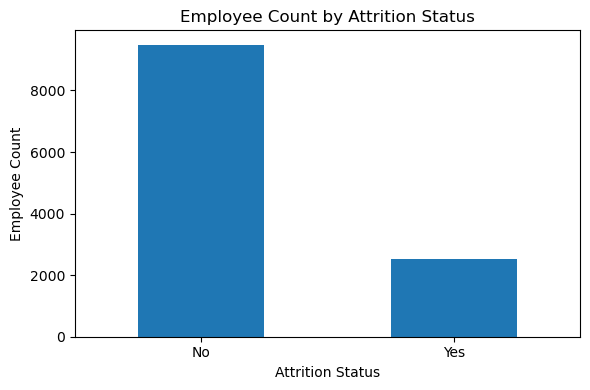

In [11]:
attrition_counts = employee_df["attrition"].value_counts()

plt.figure(figsize=(6, 4))
attrition_counts.plot(kind="bar")
plt.title("Employee Count by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Employee Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Workforce Distribution by Department

Understanding how employees are distributed across departments provides important context when evaluating attrition and engagement patterns.

In [12]:
dept_summary = (
    employee_df["department"]
    .value_counts()
    .rename_axis("department")
    .reset_index(name="employee_count")
)

dept_summary

,department,employee_count
0,Engineering,2436
1,Sales,1737
2,Customer Support,1457
3,Product,1256
4,Marketing,1076
5,HR,963
6,Operations,958
7,Finance,920
8,IT,717
9,Legal,480


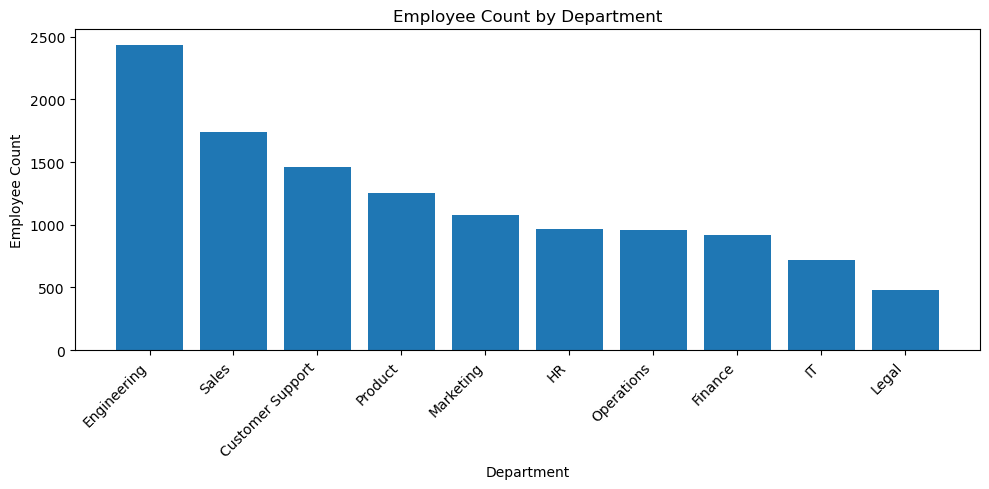

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(dept_summary["department"], dept_summary["employee_count"])
plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Engagement Score Distribution

This section examines the distribution of employee engagement scores to understand overall workforce sentiment.

In [14]:
employee_df["engagement_score"].describe()

count    12000.000000
mean        69.784417
std         12.680918
min         25.000000
25%         61.000000
50%         70.000000
75%         78.000000
max         98.000000
Name: engagement_score, dtype: float64

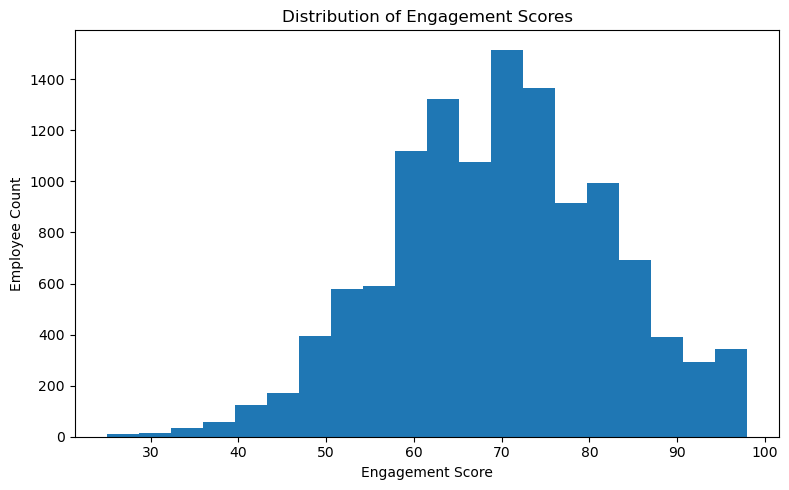

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(employee_df["engagement_score"], bins=20)
plt.title("Distribution of Engagement Scores")
plt.xlabel("Engagement Score")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

## Attrition Rate by Department

This analysis identifies which departments are experiencing higher levels of employee attrition, helping prioritize areas for HR intervention.

In [16]:
attrition_by_department = (
    employee_df.groupby("department")
    .agg(
        total_employees=("employee_id", "count"),
        attrition_count=("attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

attrition_by_department["attrition_rate_pct"] = (
    attrition_by_department["attrition_count"] / attrition_by_department["total_employees"] * 100
).round(2)

attrition_by_department["attrition_rate_label"] = (
    attrition_by_department["attrition_rate_pct"].astype(str) + "%"
)

attrition_by_department = attrition_by_department.sort_values(
    by="attrition_rate_pct", ascending=False
)

attrition_by_department

,department,total_employees,attrition_count,attrition_rate_pct,attrition_rate_label
0,Customer Support,1457,417,28.62,28.62%
9,Sales,1737,490,28.21,28.21%
2,Finance,920,201,21.85,21.85%
7,Operations,958,195,20.35,20.35%
4,IT,717,140,19.53,19.53%
6,Marketing,1076,197,18.31,18.31%
1,Engineering,2436,442,18.14,18.14%
5,Legal,480,84,17.50,17.5%
8,Product,1256,216,17.20,17.2%
3,HR,963,140,14.54,14.54%


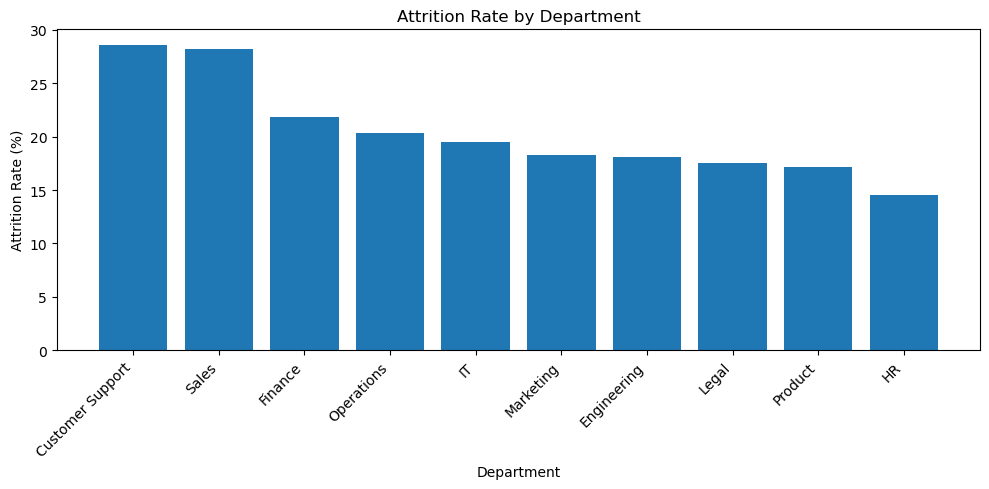

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(
    attrition_by_department["department"],
    attrition_by_department["attrition_rate_pct"]
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Attrition Rate by Tenure Bin

This analysis evaluates whether employee attrition is concentrated within specific tenure ranges, helping identify potential onboarding or early retention challenges.

In [18]:
# Create tenure bins
employee_df["tenure_bin"] = pd.cut(
    employee_df["tenure_months"],
    bins=[0, 12, 24, 60, 120, 1000],
    labels=["Under 1 Year", "1-2 Years", "2-5 Years", "5-10 Years", "10+ Years"]
)

# Calculate attrition by tenure bin
attrition_by_tenure = (
    employee_df.groupby("tenure_bin")
    .agg(
        total_employees=("employee_id", "count"),
        attrition_count=("attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

attrition_by_tenure["attrition_rate_pct"] = (
    attrition_by_tenure["attrition_count"] / attrition_by_tenure["total_employees"] * 100
).round(2)

attrition_by_tenure

,tenure_bin,total_employees,attrition_count,attrition_rate_pct
0,Under 1 Year,293,92,31.40
1,1-2 Years,897,236,26.31
2,2-5 Years,4387,889,20.26
3,5-10 Years,4859,997,20.52
4,10+ Years,1564,308,19.69


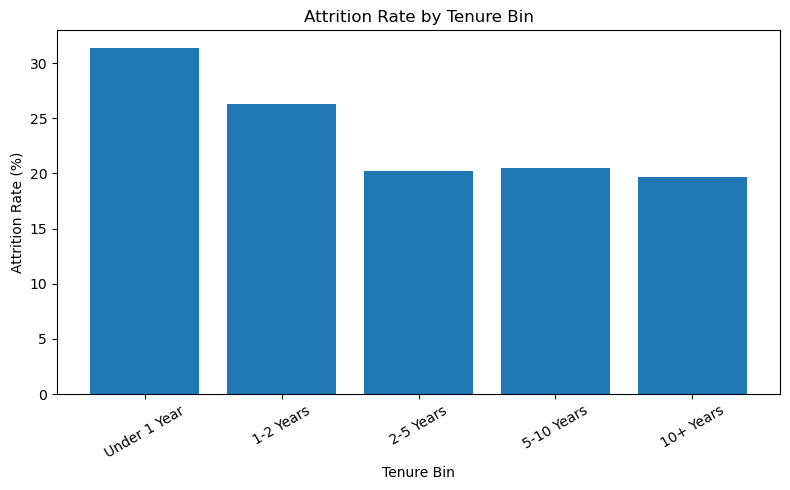

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(
    attrition_by_tenure["tenure_bin"],
    attrition_by_tenure["attrition_rate_pct"]
)

plt.title("Attrition Rate by Tenure Bin")
plt.xlabel("Tenure Bin")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Attrition by Promotion History

This analysis evaluates whether employees who have not received recent promotions are more likely to leave the organization, helping identify potential career growth or advancement gaps.

In [20]:
attrition_by_promotion = (
    employee_df.groupby("promotion_last_2yrs")
    .agg(
        total_employees=("employee_id", "count"),
        attrition_count=("attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

attrition_by_promotion["attrition_rate_pct"] = (
    attrition_by_promotion["attrition_count"] / attrition_by_promotion["total_employees"] * 100
).round(2)

# Further define labels
attrition_by_promotion["promotion_status"] = attrition_by_promotion["promotion_last_2yrs"].map({
    1: "Promoted (Last 2 Years)",
    0: "No Recent Promotion"
})

attrition_by_promotion

,promotion_last_2yrs,total_employees,attrition_count,attrition_rate_pct,promotion_status
0,0,9350,2064,22.07,No Recent Promotion
1,1,2650,458,17.28,Promoted (Last 2 Years)


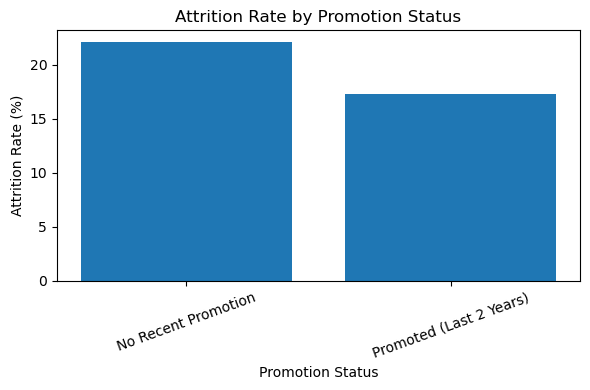

In [21]:
plt.figure(figsize=(6, 4))
plt.bar(
    attrition_by_promotion["promotion_status"],
    attrition_by_promotion["attrition_rate_pct"]
)

plt.title("Attrition Rate by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Engagement vs Attrition

This analysis examines the relationship between employee engagement levels and attrition outcomes to determine whether lower engagement is associated with a higher likelihood of leaving.

In [22]:
engagement_by_attrition = (
    employee_df.groupby("attrition")
    .agg(
        total_employees=("employee_id", "count"),
        avg_engagement_score=("engagement_score", "mean")
    )
    .reset_index()
)

engagement_by_attrition

,attrition,total_employees,avg_engagement_score
0,No,9478,70.831294
1,Yes,2522,65.850119


In [23]:
engagement_by_attrition["avg_engagement_score"] = (
    engagement_by_attrition["avg_engagement_score"].round(2)
)

engagement_by_attrition

,attrition,total_employees,avg_engagement_score
0,No,9478,70.83
1,Yes,2522,65.85


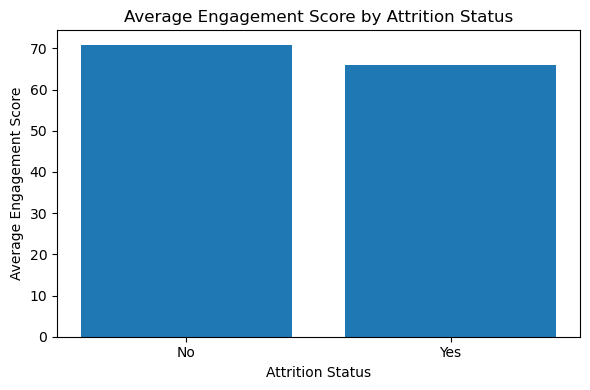

In [24]:
plt.figure(figsize=(6, 4))
plt.bar(
    engagement_by_attrition["attrition"],
    engagement_by_attrition["avg_engagement_score"]
)

plt.title("Average Engagement Score by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Create engagement bins
employee_df["engagement_bin"] = pd.cut(
    employee_df["engagement_score"],
    bins=[0, 50, 65, 80, 100],
    labels=["Low (<50)", "Moderate (50-64)", "High (65-79)", "Very High (80+)"]
)

# Calculate attrition by engagement bin
attrition_by_engagement = (
    employee_df.groupby("engagement_bin")
    .agg(
        total_employees=("employee_id", "count"),
        attrition_count=("attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

attrition_by_engagement["attrition_rate_pct"] = (
    attrition_by_engagement["attrition_count"] / attrition_by_engagement["total_employees"] * 100
).round(2)

attrition_by_engagement

,engagement_bin,total_employees,attrition_count,attrition_rate_pct
0,Low (<50),803,361,44.96
1,Moderate (50-64),3612,863,23.89
2,High (65-79),5131,933,18.18
3,Very High (80+),2454,365,14.87


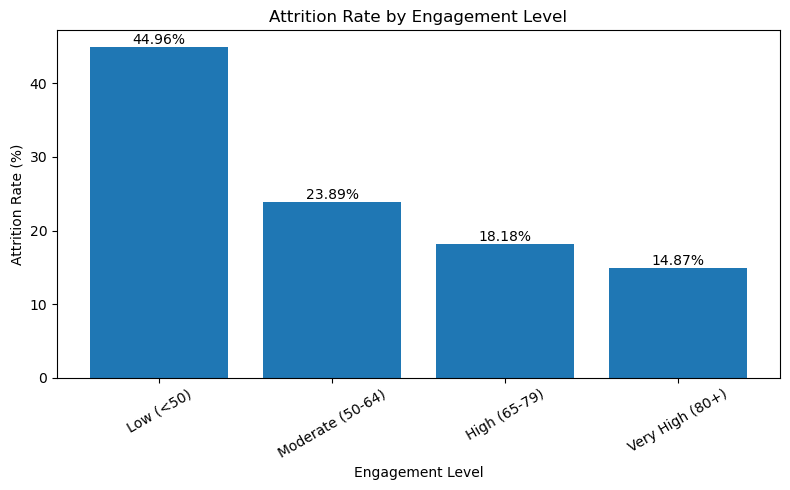

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    attrition_by_engagement["engagement_bin"],
    attrition_by_engagement["attrition_rate_pct"]
)

plt.title("Attrition Rate by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=30)

# Add labels to bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## Survey Sentiment vs Attrition

This analysis evaluates how employee survey responses (specifically, satisfaction, work-life balance, and manager effectiveness) relate to attrition outcomes, providing insight into employee experience drivers.

In [27]:
# Get each employee's most recent survey
latest_survey = (
    survey_df.sort_values("survey_date")
    .groupby("employee_id")
    .tail(1)
)

# Merge with employee data
employee_survey_df = employee_df.merge(
    latest_survey,
    on="employee_id",
    how="left"
)

employee_survey_df.head()

,employee_id,age,gender,location,department,job_role,tenure_months,salary,performance_rating,engagement_score,promotion_last_2yrs,remote_status,attrition,tenure_bin,engagement_bin,survey_id,survey_date,satisfaction_score,work_life_balance_score,manager_effectiveness_score
0,E00001,29,Male,Seattle,HR,HR Analyst,97,125200,4,75,0,Remote,No,5-10 Years,High (65-79),S00001_2,2025-11-21,8,7,10
1,E00002,53,Male,Austin,Marketing,Campaign Manager,47,113800,3,61,1,Remote,No,2-5 Years,Moderate (50-64),S00002_2,2025-11-15,5,4,5
2,E00003,28,Female,Seattle,HR,HR Analyst,36,97000,3,62,0,Hybrid,No,2-5 Years,Moderate (50-64),S00003_1,2025-09-07,6,4,8
3,E00004,41,Female,Austin,Product,Product Analyst,71,152700,4,71,0,Onsite,Yes,5-10 Years,High (65-79),S00004_1,2025-09-07,6,10,8
4,E00005,41,Female,Atlanta,Product,Program Manager,28,113700,3,63,0,Onsite,No,2-5 Years,Moderate (50-64),S00005_2,2025-10-01,6,7,6


In [28]:
survey_by_attrition = (
    employee_survey_df.groupby("attrition")
    .agg(
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_work_life_balance=("work_life_balance_score", "mean"),
        avg_manager_effectiveness=("manager_effectiveness_score", "mean")
    )
    .reset_index()
)

survey_by_attrition = survey_by_attrition.round(2)

survey_by_attrition

,attrition,avg_satisfaction,avg_work_life_balance,avg_manager_effectiveness
0,No,7.02,7.09,7.03
1,Yes,6.60,6.56,6.50


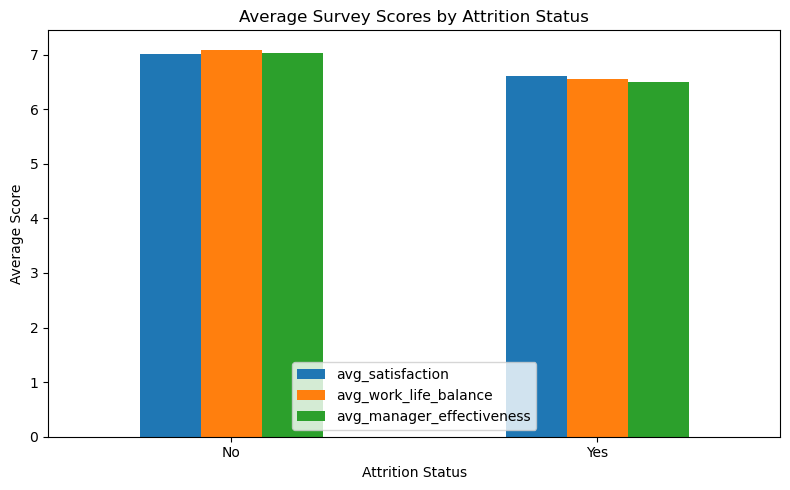

In [29]:
survey_by_attrition.set_index("attrition").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Survey Scores by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## High-Risk Employee Identification

This section defines a simple rule-based model to identify employees at higher risk of attrition based on key factors identified in prior analysis.

In [30]:
# Create risk flags
employee_survey_df["high_risk_flag"] = (
    (employee_survey_df["engagement_score"] < 60) &
    (employee_survey_df["promotion_last_2yrs"] == 0) &
    (employee_survey_df["tenure_months"] < 24) &
    (employee_survey_df["satisfaction_score"] <= 6.5)
).astype(int)

In [31]:
employee_survey_df["high_risk_flag"].value_counts()

high_risk_flag
0    11835
1      165
Name: count, dtype: int64

In [32]:
risk_summary = (
    employee_survey_df.groupby("high_risk_flag")
    .agg(
        total_employees=("employee_id", "count"),
        attrition_rate=("attrition", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

risk_summary["attrition_rate"] = risk_summary["attrition_rate"].round(2)

risk_summary

,high_risk_flag,total_employees,attrition_rate
0,0,11835,20.69
1,1,165,44.24


In [33]:
risk_summary["risk_group"] = risk_summary["high_risk_flag"].map({
    1: "High Risk",
    0: "Lower Risk"
})

risk_summary

,high_risk_flag,total_employees,attrition_rate,risk_group
0,0,11835,20.69,Lower Risk
1,1,165,44.24,High Risk


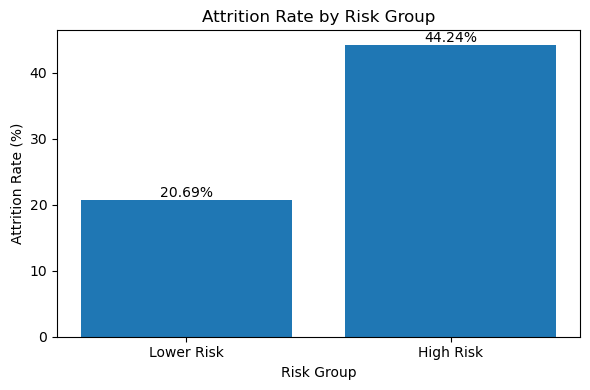

In [34]:
plt.figure(figsize=(6, 4))
plt.bar(
    risk_summary["risk_group"],
    risk_summary["attrition_rate"]
)

plt.title("Attrition Rate by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Attrition Rate (%)")

# Add labels
for i, v in enumerate(risk_summary["attrition_rate"]):
    plt.text(i, v, f"{v}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Key Takeaways

- Attrition is highest among employees in their first two years, suggesting onboarding and early experience may be critical drivers.
- Employees without recent promotions exhibit higher attrition rates, indicating potential gaps in career progression.
- Lower engagement scores are strongly associated with higher attrition, highlighting engagement as a key retention lever.
- Employees who leave report consistently lower satisfaction, work-life balance, and manager effectiveness scores.
- A simple rule-based model combining engagement, tenure, promotion history, and satisfaction identifies a high-risk group with more than double the attrition rate of the overall population.

These findings suggest that targeted interventions focused on early tenure employees, career development, engagement, and employee experience could meaningfully improve retention outcomes.